# BCO7006 — Session 11 · INSTRUCTOR
# Data Visualization (Matplotlib · Seaborn · Plotly)

This is the instructor copy: every student exercise is solved, with common-wrong-answer notes, an L5 rubric for the open task, and AI-disclosure guidance. **Do not distribute to students.**

## 0 · The friction

In [1]:
import pandas as pd
df = pd.read_csv('shopping_cart.csv')
df.head(10)

,User_ID,Product_ID,Product_Category,Quantity,Price
0,45,35,Books,2,66.988863
1,48,41,Clothes,4,57.501358
2,65,34,Books,2,28.864011
3,68,29,Books,5,35.784971
4,68,5,Groceries,8,79.875638
5,10,27,Electronics,6,20.432819
6,84,33,Books,7,12.750205
7,22,46,Books,3,53.752548
8,37,10,Groceries,6,26.026326
9,88,6,Electronics,3,27.070067


In [2]:
print(df.shape); df.info(); df.describe()

(500, 5)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           500 non-null    int64  
 1   Product_ID        500 non-null    int64  
 2   Product_Category  500 non-null    str    
 3   Quantity          500 non-null    int64  
 4   Price             500 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 19.7 KB


,User_ID,Product_ID,Quantity,Price
count,500.000000,500.000000,500.000000,500.000000
mean,48.794000,24.980000,4.992000,52.478765
std,28.218649,14.220268,2.613349,27.491078
min,1.000000,1.000000,1.000000,5.068111
25%,25.000000,12.750000,3.000000,28.801351
50%,47.500000,26.000000,5.000000,53.093532
75%,73.000000,37.250000,7.000000,77.007687
max,99.000000,49.000000,9.000000,99.986114


> 🧑‍🏫 **Instructor note** — The three opening questions are deliberately unanswerable from the table. Don't rush this — let a student *try* to answer Q1 from the numbers and fail. That failure is the motivation for the whole session.

## 1 · Matplotlib

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

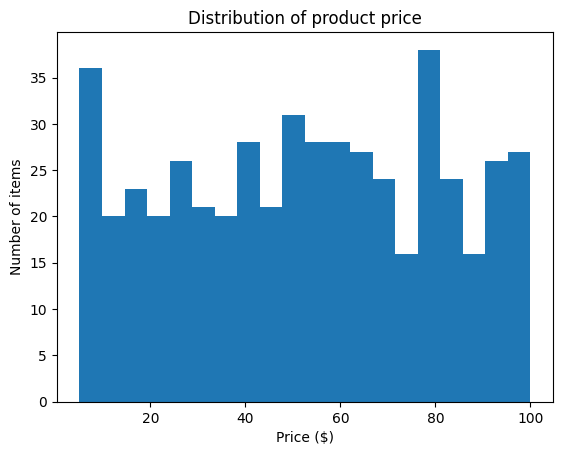

In [4]:
plt.hist(df['Price'], bins=20)
plt.title('Distribution of product price'); plt.xlabel('Price ($)'); plt.ylabel('Number of items'); plt.show()

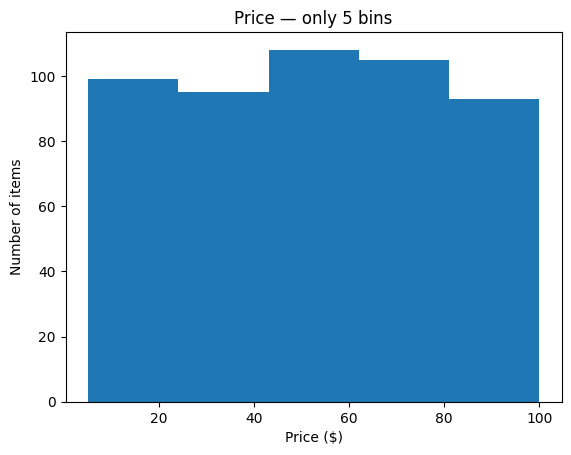

In [5]:
plt.hist(df['Price'], bins=5)
plt.title('Price — only 5 bins'); plt.xlabel('Price ($)'); plt.ylabel('Number of items'); plt.show()

> 🧑‍🏫 **Instructor note** — Trace answer: fewer bars, each *wider*. Common wrong prediction: students say 'fewer **and** narrower' — they conflate bin count with bar width. Point out total area is unchanged.

Product_Category
Books          31980.299330
Clothes        33461.680116
Electronics    31199.625557
Groceries      34259.559370
Name: LineTotal, dtype: float64


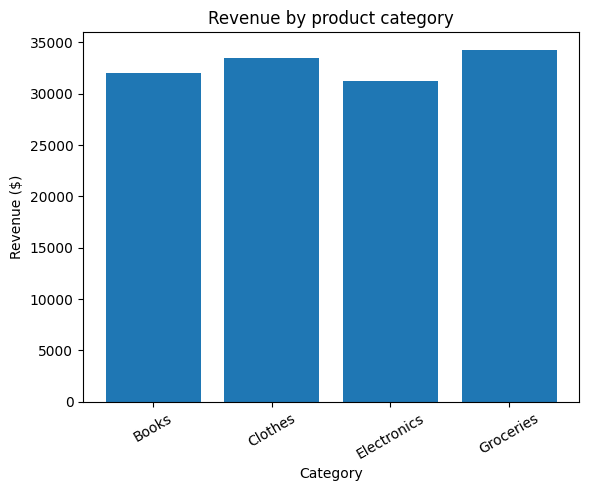

In [6]:
df['LineTotal'] = df['Quantity'] * df['Price']
revenue = df.groupby('Product_Category')['LineTotal'].sum()
print(revenue)
plt.bar(revenue.index, revenue.values)
plt.title('Revenue by product category'); plt.xlabel('Category'); plt.ylabel('Revenue ($)'); plt.xticks(rotation=30); plt.show()

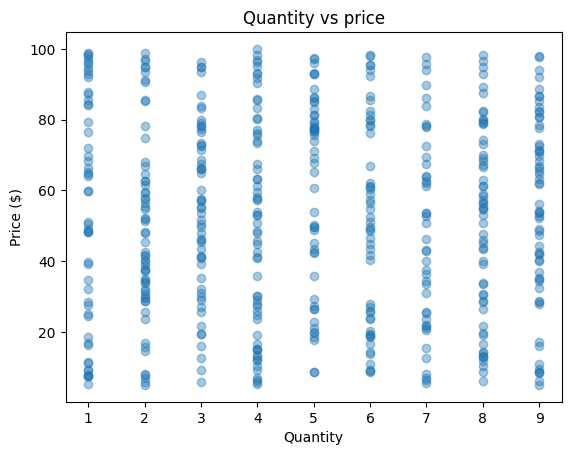

In [7]:
plt.scatter(df['Quantity'], df['Price'], alpha=0.4)
plt.title('Quantity vs price'); plt.xlabel('Quantity'); plt.ylabel('Price ($)'); plt.show()

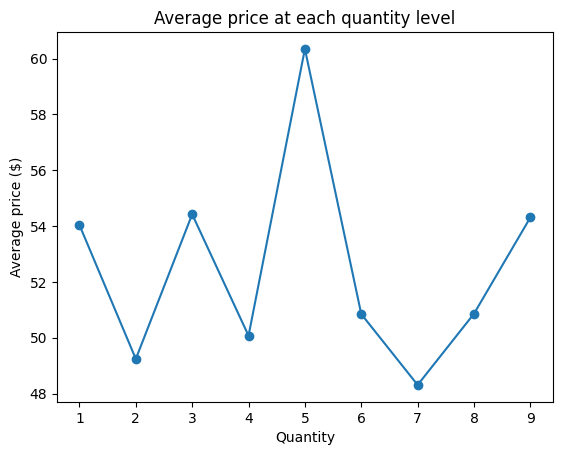

In [8]:
avg_price = df.groupby('Quantity')['Price'].mean()
plt.plot(avg_price.index, avg_price.values, marker='o')
plt.title('Average price at each quantity level'); plt.xlabel('Quantity'); plt.ylabel('Average price ($)'); plt.show()

**Pause-and-try solution — histogram of Quantity, 15 bins:**

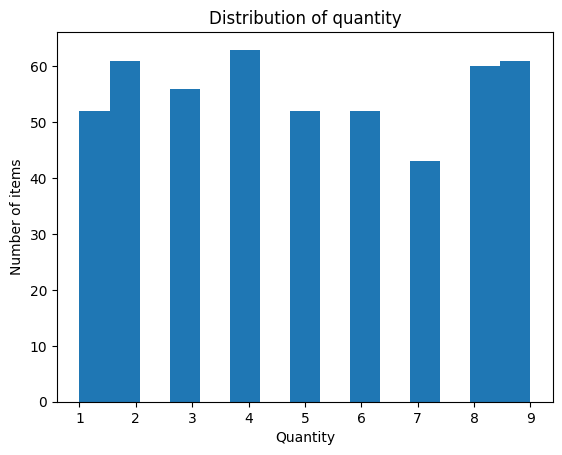

In [9]:
plt.hist(df['Quantity'], bins=15)
plt.title('Distribution of quantity'); plt.xlabel('Quantity'); plt.ylabel('Number of items'); plt.show()

> 🧑‍🏫 **Instructor note** — Common errors: (a) forgetting `plt.show()` so two plots overlay; (b) passing the column name as a string `'Quantity'` instead of `df['Quantity']` → Matplotlib plots the literal letters.

## 2 · Seaborn

In [10]:
import seaborn as sns
sns.set_theme()

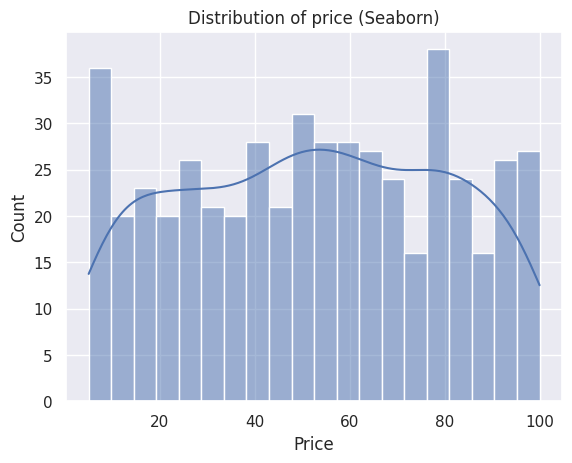

In [11]:
sns.histplot(data=df, x='Price', bins=20, kde=True)
plt.title('Distribution of price (Seaborn)'); plt.show()

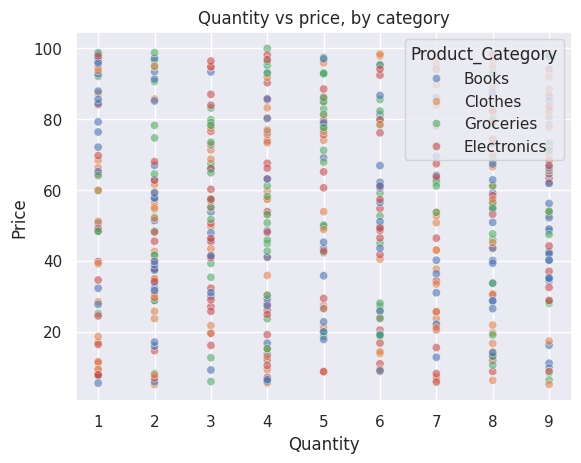

In [12]:
sns.scatterplot(data=df, x='Quantity', y='Price', hue='Product_Category', alpha=0.6)
plt.title('Quantity vs price, by category'); plt.show()

**Pause-and-try solution — average price per category with `sns.barplot`:**

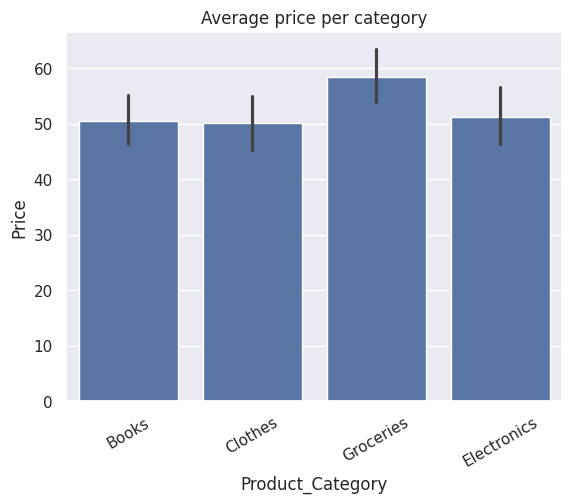

In [13]:
sns.barplot(data=df, x='Product_Category', y='Price')
plt.title('Average price per category'); plt.xticks(rotation=30); plt.show()

> 🧑‍🏫 **Instructor note** — `sns.barplot` defaults to the **mean** with a 95% CI bar. Students often expect a sum (like the Matplotlib revenue chart) — clarify that barplot aggregates by mean unless told otherwise (`estimator=sum`).

## 3 · Plotly

In [14]:
import plotly.express as px
fig = px.scatter(df, x='Quantity', y='Price', color='Product_Category',
                 hover_data=['User_ID', 'Product_ID'], title='Quantity vs price (interactive)')
fig.show()

In [15]:
fig.write_html('quantity_vs_price.html')
print('Saved quantity_vs_price.html')

Saved quantity_vs_price.html


**Pause-and-try solution — interactive Plotly histogram of Price:**

In [16]:
fig_h = px.histogram(df, x='Price', nbins=20, title='Price distribution (interactive)')
fig_h.show()

## 5 · Mini-project — reference answers

> 🧑‍🏫 **Instructor note** — Mark the **plot choice**, not the syntax. A correct choice with a small syntax slip scores higher than a clean plot of the wrong type.

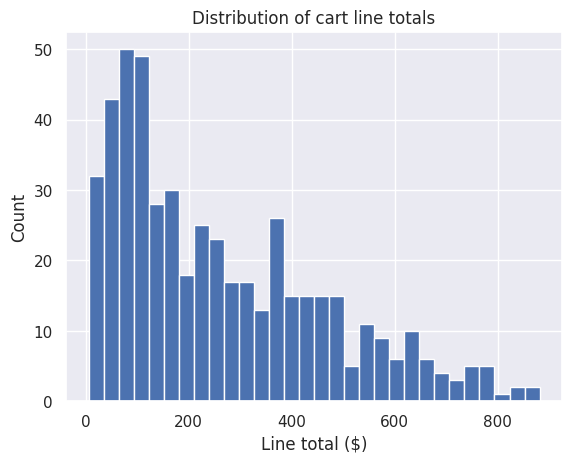

In [17]:
# Q1 — distribution of one numeric column -> histogram
plt.hist(df['LineTotal'], bins=30)
plt.title('Distribution of cart line totals'); plt.xlabel('Line total ($)'); plt.ylabel('Count'); plt.show()
# Finding: right-skewed with a long tail — a few large carts dominate spend.

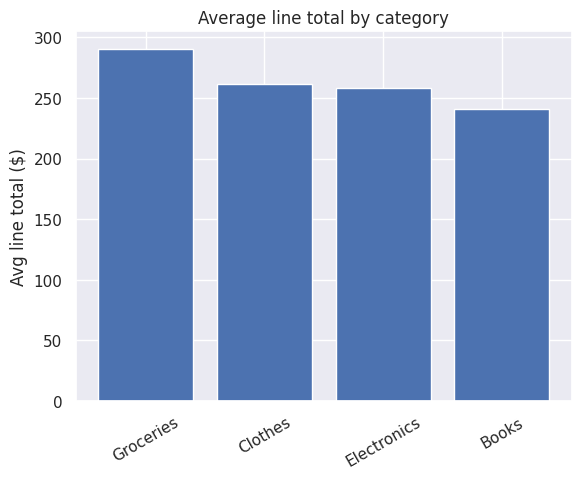

Product_Category
Groceries    290.335249
Name: LineTotal, dtype: float64


In [18]:
# Q2 — a value per category -> bar of the MEAN line total
avg_lt = df.groupby('Product_Category')['LineTotal'].mean().sort_values(ascending=False)
plt.bar(avg_lt.index, avg_lt.values); plt.xticks(rotation=30)
plt.title('Average line total by category'); plt.ylabel('Avg line total ($)'); plt.show()
print(avg_lt.head(1))

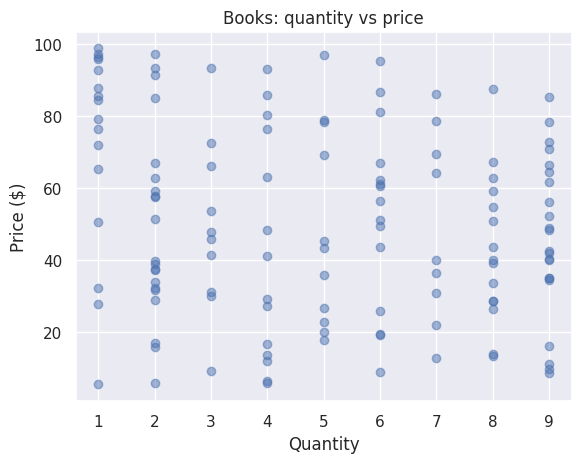

In [19]:
# Q3 — relationship between two numeric columns, filtered -> scatter
books = df[df['Product_Category'] == 'Books']
plt.scatter(books['Quantity'], books['Price'], alpha=0.5)
plt.title('Books: quantity vs price'); plt.xlabel('Quantity'); plt.ylabel('Price ($)'); plt.show()
# Finding: no clear relationship — price looks independent of quantity (data is randomly generated).

In [20]:
# Open question — example: interactive revenue-by-category bar, exported
rev = df.groupby('Product_Category')['LineTotal'].sum().reset_index()
fig_o = px.bar(rev, x='Product_Category', y='LineTotal', title='Revenue by category (interactive)')
fig_o.write_html('revenue_by_category.html')
fig_o.show()

> 🧑‍🏫 **Instructor note** — **L5 (open question) rubric — engagement-based, no single correct answer.** Pass = a sensible question + a plot type that genuinely fits it + an exported interactive file + a one-line interpretation. Distinction = the interpretation is data-aware (notes skew, an outlier, or that the synthetic data shows no real signal). There is no 'right' question; reward judgement, not cleverness.

## 6 · AI critique — reference

> 🧑‍🏫 **Instructor note** — The snippet is wrong in three ways students should find: (1) it plots **every row**, not an average; (2) a **line** plot over a categorical x-axis is meaningless and connects unrelated categories; (3) 500 category strings on the x-axis become an unreadable smear. The fix groups to a mean and uses a bar.

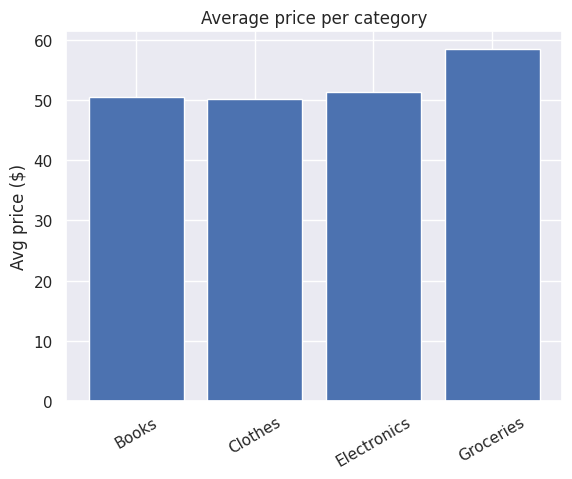

In [21]:
# Corrected:
avg = df.groupby('Product_Category')['Price'].mean()
plt.bar(avg.index, avg.values); plt.xticks(rotation=30)
plt.title('Average price per category'); plt.ylabel('Avg price ($)'); plt.show()

> 🧑‍🏫 **Instructor note** — **AI-disclosure guidance.** Calibrated, not punitive. Patterns worth a follow-up conversation (not a formal referral): a reflection cell left blank while the code uses advanced styling not taught here; pasted code that references columns that don't exist in this dataset (sign of an ungrounded prompt); or identical idiosyncratic variable names across many students. Approach: ask the student to walk you through one plot live. The goal is to make AI use *visible*, which the reflection cell already does — most disclosures are honest.

## 7 · Skill check — answer key
1. `bins`   2. `xlabel`   3. `hue`   4. `sum`   5. `write_html`

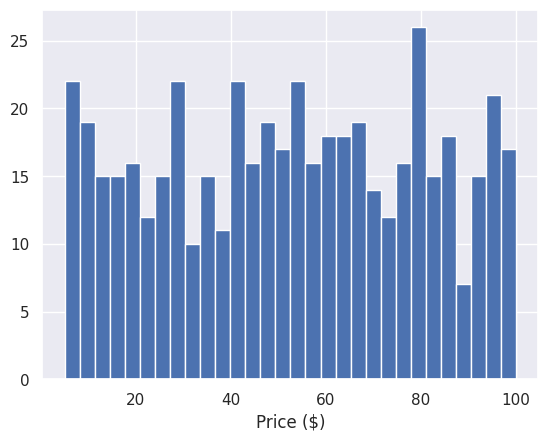

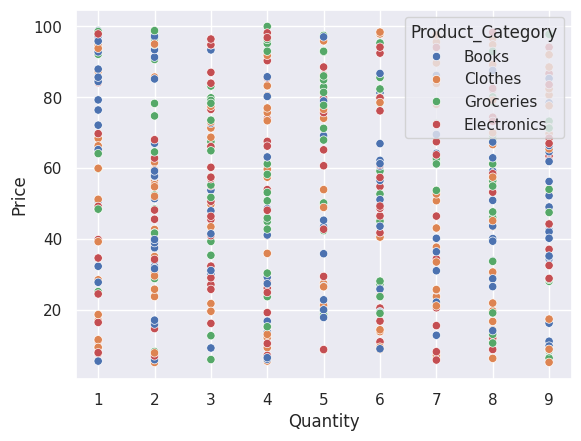

Product_Category
Books          31980.299330
Clothes        33461.680116
Electronics    31199.625557
Groceries      34259.559370
Name: LineTotal, dtype: float64


In [22]:
# Verify the answer key runs:
plt.hist(df['Price'], bins=30); plt.xlabel('Price ($)'); plt.show()
sns.scatterplot(data=df, x='Quantity', y='Price', hue='Product_Category'); plt.show()
print(df.groupby('Product_Category')['LineTotal'].sum())